In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import cv2
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tqdm import tqdm
import os
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
from tensorflow.keras.applications import EfficientNetB1
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, TensorBoard, ModelCheckpoint
from sklearn.metrics import classification_report,confusion_matrix
import ipywidgets as widgets
import io
from PIL import Image
from IPython.display import display,clear_output
from warnings import filterwarnings
from sklearn.preprocessing import OneHotEncoder 

2026-02-17 10:14:56.446829: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771323296.676178      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771323296.730249      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771323297.235501      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771323297.235555      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771323297.235558      24 computation_placer.cc:177] computation placer alr

In [2]:
encoder = OneHotEncoder()
encoder.fit([[0], [1], [2], [3]]) 

# 0 - Tumor
# 1 - pituitary
# 2 - giloma
# 3 - meningioma

OneHotEncoder()

In [3]:
labels = ['glioma_tumor','no_tumor','meningioma_tumor','pituitary_tumor']

In [4]:
X_train = []
y_train = []
image_size = 224
for i in labels:
    folderPath = os.path.join('/kaggle/input/datasets/sartajbhuvaji/brain-tumor-classification-mri','Training',i)
    for j in tqdm(os.listdir(folderPath)):
        img = cv2.imread(os.path.join(folderPath,j))
        img = cv2.resize(img,(image_size, image_size))
        X_train.append(img)
        y_train.append(i)
        
for i in labels:
    folderPath = os.path.join('/kaggle/input/datasets/sartajbhuvaji/brain-tumor-classification-mri','Testing',i)
    for j in tqdm(os.listdir(folderPath)):
        img = cv2.imread(os.path.join(folderPath,j))
        img = cv2.resize(img,(image_size,image_size))
        X_train.append(img)
        y_train.append(i)
        
X_train = np.array(X_train)
y_train = np.array(y_train)

100%|██████████| 74/74 [00:00<00:00, 94.40it/s]


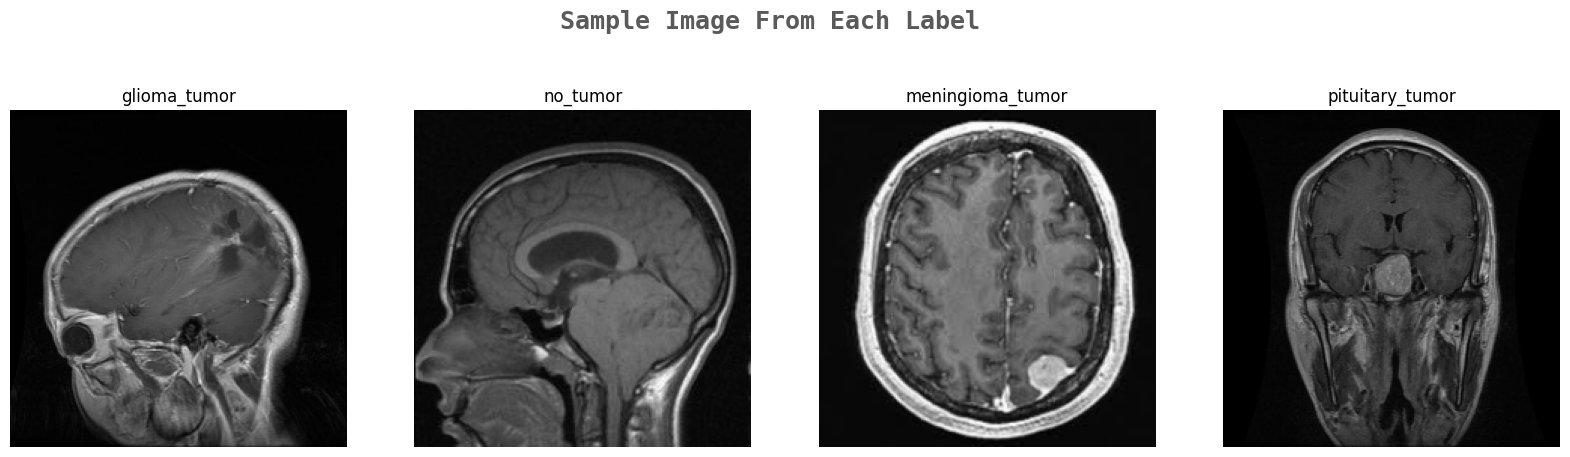

In [5]:
k=0
fig, ax = plt.subplots(1,4,figsize=(20,20))
fig.text(s='Sample Image From Each Label',size=18,fontweight='bold',
             fontname='monospace',color='#313131',y=0.62,x=0.4,alpha=0.8)
for i in labels:
    j=0
    while True :
        if y_train[j]==i:
            ax[k].imshow(X_train[j])
            ax[k].set_title(y_train[j])
            ax[k].axis('off')
            k+=1
            break
        j+=1

In [6]:
X_train, y_train = shuffle(X_train,y_train, random_state=101)

In [7]:
X_train.shape

(3264, 224, 224, 3)

In [8]:
X_train,X_test,y_train,y_test = train_test_split(X_train,y_train, test_size=0.2,random_state=101)

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

<Axes: xlabel='count'>

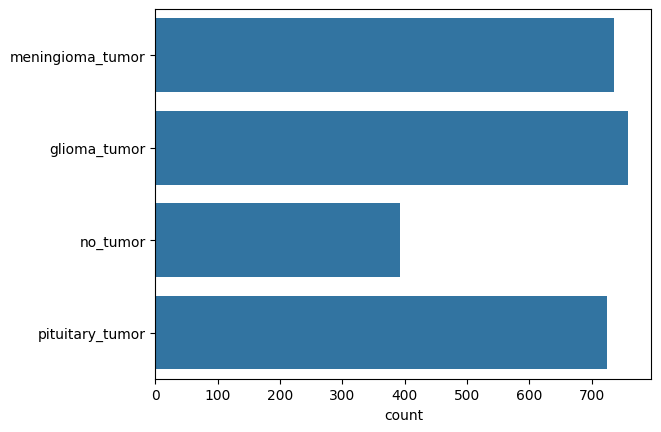

In [10]:
sns.countplot(y_train)

<Axes: xlabel='count'>

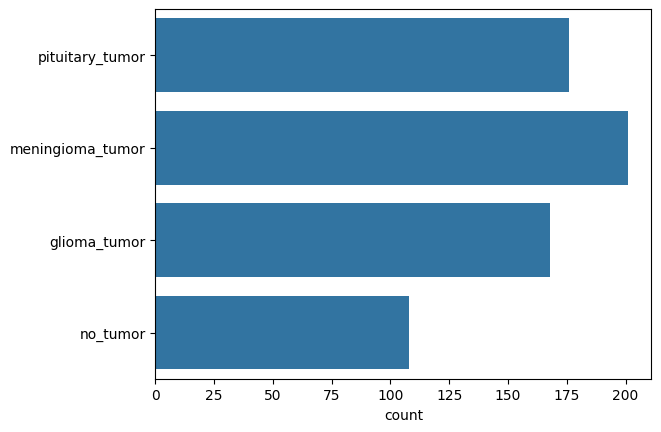

In [11]:
sns.countplot(y_test)

In [12]:
y_train_new = []
for i in y_train:
    y_train_new.append(labels.index(i))
y_train = y_train_new
y_train = tf.keras.utils.to_categorical(y_train)


y_test_new = []
for i in y_test:
    y_test_new.append(labels.index(i))
y_test = y_test_new
y_test = tf.keras.utils.to_categorical(y_test)

In [13]:
effnet = EfficientNetB1(weights='imagenet',include_top=False,input_shape=(image_size,image_size,3))

I0000 00:00:1771323340.040848      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1771323340.046947      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


27018416/27018416 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [14]:
model = effnet.output
model = tf.keras.layers.GlobalAveragePooling2D()(model)
model = tf.keras.layers.Dropout(rate=0.5)(model)
model = tf.keras.layers.Dense(4,activation='softmax')(model)
model = tf.keras.models.Model(inputs=effnet.input, outputs = model)

In [15]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 6,580,363 (25.10 MB)

 Trainable params: 6,518,308 (24.87 MB)

 Non-trainable params: 62,055 (242.41 KB)

In [16]:
model.compile(loss='categorical_crossentropy',optimizer = 'Adam', metrics= ['accuracy'])

In [17]:
tensorboard = TensorBoard(log_dir = 'logs')
checkpoint = ModelCheckpoint("effnet.h5",monitor="val_accuracy",save_best_only=True,mode="auto",verbose=1)
reduce_lr = ReduceLROnPlateau(monitor = 'val_accuracy', factor = 0.3, patience = 2, min_delta = 0.001, mode='auto',verbose=1)

In [18]:
history = model.fit(X_train,y_train,validation_split=0.1, epochs =10, verbose=1, batch_size=32,
                   callbacks=[tensorboard,checkpoint,reduce_lr])

Epoch 1/10


I0000 00:00:1771323394.420164      74 service.cc:152] XLA service 0x7905f4153b70 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1771323394.420209      74 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1771323394.420217      74 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1771323403.295992      74 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-02-17 10:16:56.374058: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-17 10:16:56.517170: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-17 10:16:56.861201: E external/local_xl

73/74 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - accuracy: 0.7417 - loss: 0.6568

2026-02-17 10:18:09.688489: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-17 10:18:09.826308: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-17 10:18:10.155664: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-17 10:18:10.295545: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-17 10:18:11.058994: E external/local_xla/xla/stream_

74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 937ms/step - accuracy: 0.7428 - loss: 0.6544

...

74/74 ━━━━━━━━━━━━━━━━━━━━ 208s 1s/step - accuracy: 0.7439 - loss: 0.6520 - val_accuracy: 0.8321 - val_loss: 0.5939 - learning_rate: 0.0010
Epoch 2/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - accuracy: 0.9320 - loss: 0.1972
Epoch 2: val_accuracy improved from 0.83206 to 0.89313, saving model to effnet.h5


74/74 ━━━━━━━━━━━━━━━━━━━━ 14s 183ms/step - accuracy: 0.9321 - loss: 0.1969 - val_accuracy: 0.8931 - val_loss: 0.3753 - learning_rate: 0.0010
Epoch 3/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.9475 - loss: 0.1574
Epoch 3: val_accuracy did not improve from 0.89313
74/74 ━━━━━━━━━━━━━━━━━━━━ 13s 172ms/step - accuracy: 0.9476 - loss: 0.1573 - val_accuracy: 0.8588 - val_loss: 0.5529 - learning_rate: 0.0010
Epoch 4/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - accuracy: 0.9568 - loss: 0.1279
Epoch 4: val_accuracy improved from 0.89313 to 0.92748, saving model to effnet.h5


74/74 ━━━━━━━━━━━━━━━━━━━━ 14s 190ms/step - accuracy: 0.9568 - loss: 0.1277 - val_accuracy: 0.9275 - val_loss: 0.2602 - learning_rate: 0.0010
Epoch 5/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - accuracy: 0.9600 - loss: 0.1182
Epoch 5: val_accuracy improved from 0.92748 to 0.95420, saving model to effnet.h5


74/74 ━━━━━━━━━━━━━━━━━━━━ 14s 193ms/step - accuracy: 0.9601 - loss: 0.1178 - val_accuracy: 0.9542 - val_loss: 0.1785 - learning_rate: 0.0010
Epoch 6/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step - accuracy: 0.9834 - loss: 0.0511
Epoch 6: val_accuracy did not improve from 0.95420
74/74 ━━━━━━━━━━━━━━━━━━━━ 14s 184ms/step - accuracy: 0.9834 - loss: 0.0512 - val_accuracy: 0.8855 - val_loss: 0.4129 - learning_rate: 0.0010
Epoch 7/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step - accuracy: 0.9842 - loss: 0.0507
Epoch 7: val_accuracy improved from 0.95420 to 0.96565, saving model to effnet.h5


74/74 ━━━━━━━━━━━━━━━━━━━━ 15s 204ms/step - accuracy: 0.9843 - loss: 0.0505 - val_accuracy: 0.9656 - val_loss: 0.1402 - learning_rate: 0.0010
Epoch 8/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step - accuracy: 0.9872 - loss: 0.0420
Epoch 8: val_accuracy did not improve from 0.96565
74/74 ━━━━━━━━━━━━━━━━━━━━ 14s 194ms/step - accuracy: 0.9872 - loss: 0.0422 - val_accuracy: 0.9466 - val_loss: 0.1487 - learning_rate: 0.0010
Epoch 9/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step - accuracy: 0.9837 - loss: 0.0482
Epoch 9: val_accuracy did not improve from 0.96565

Epoch 9: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.
74/74 ━━━━━━━━━━━━━━━━━━━━ 14s 188ms/step - accuracy: 0.9838 - loss: 0.0481 - val_accuracy: 0.9504 - val_loss: 0.1778 - learning_rate: 0.0010
Epoch 10/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - accuracy: 0.9849 - loss: 0.0329
Epoch 10: val_accuracy did not improve from 0.96565
74/74 ━━━━━━━━━━━━━━━━━━━━ 14s 183ms/step - accuracy: 0.9850 - loss: 0.0327 - val_ac

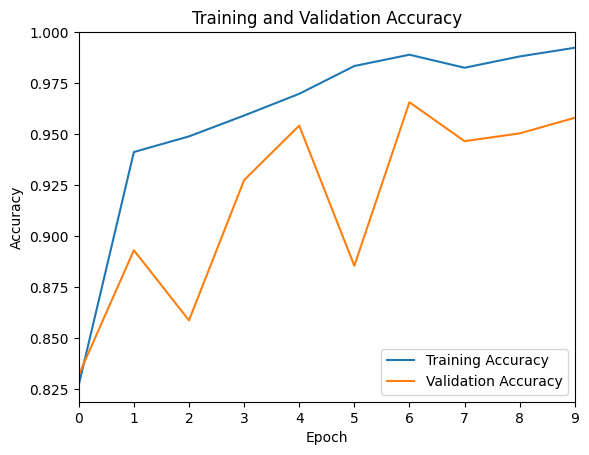

In [19]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.ylabel('Accuracy')
plt.xlim([0,9])
plt.ylim([min(plt.ylim()),1])
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.show()

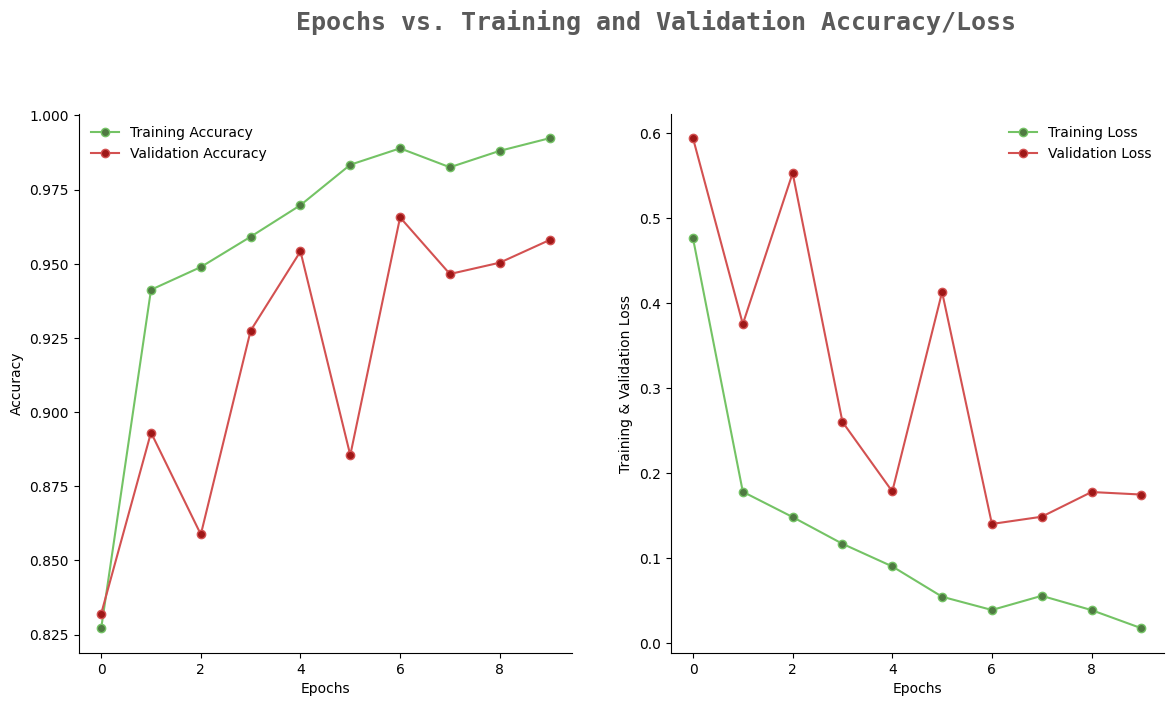

In [20]:
filterwarnings('ignore')

epochs = [i for i in range(10)]
fig, ax = plt.subplots(1,2,figsize=(14,7))
train_acc = history.history['accuracy']
train_loss = history.history['loss']
val_acc = history.history['val_accuracy']
val_loss = history.history['val_loss']

fig.text(s='Epochs vs. Training and Validation Accuracy/Loss',size=18,fontweight='bold',
             fontname='monospace',color='#313131',y=1,x=0.28,alpha=0.8)

sns.despine()
ax[0].plot(epochs, train_acc, marker='o',markerfacecolor='#4F7942',color='#74C365',
           label = 'Training Accuracy')
ax[0].plot(epochs, val_acc, marker='o',markerfacecolor='#9E1717',color='#D35151',
           label = 'Validation Accuracy')
ax[0].legend(frameon=False)
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Accuracy')

sns.despine()
ax[1].plot(epochs, train_loss, marker='o',markerfacecolor='#4F7942',color='#74C365',
           label ='Training Loss')
ax[1].plot(epochs, val_loss, marker='o',markerfacecolor='#9E1717',color='#D35151',
           label = 'Validation Loss')
ax[1].legend(frameon=False)
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Training & Validation Loss')

fig.show()

In [21]:
pred = model.predict(X_test)
pred = np.argmax(pred,axis=1)
y_test_new = np.argmax(y_test,axis=1)

21/21 ━━━━━━━━━━━━━━━━━━━━ 18s 490ms/step


In [22]:
print(classification_report(y_test_new,pred))

              precision    recall  f1-score   support

           0       0.99      0.95      0.97       168
           1       0.98      0.98      0.98       108
           2       0.97      0.97      0.97       201
           3       0.96      1.00      0.98       176

    accuracy                           0.97       653
   macro avg       0.98      0.97      0.97       653
weighted avg       0.97      0.97      0.97       653



In [23]:
cm = confusion_matrix(y_test_new, pred)

In [24]:
import itertools
from itertools import product
def plot_confusion_matrix(cm, classes,normalize=False,title='Confusion matrix',cmap=plt.cm.Blues):
    
    plt.figure(figsize=(10,10))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j],
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

Confusion matrix, without normalization


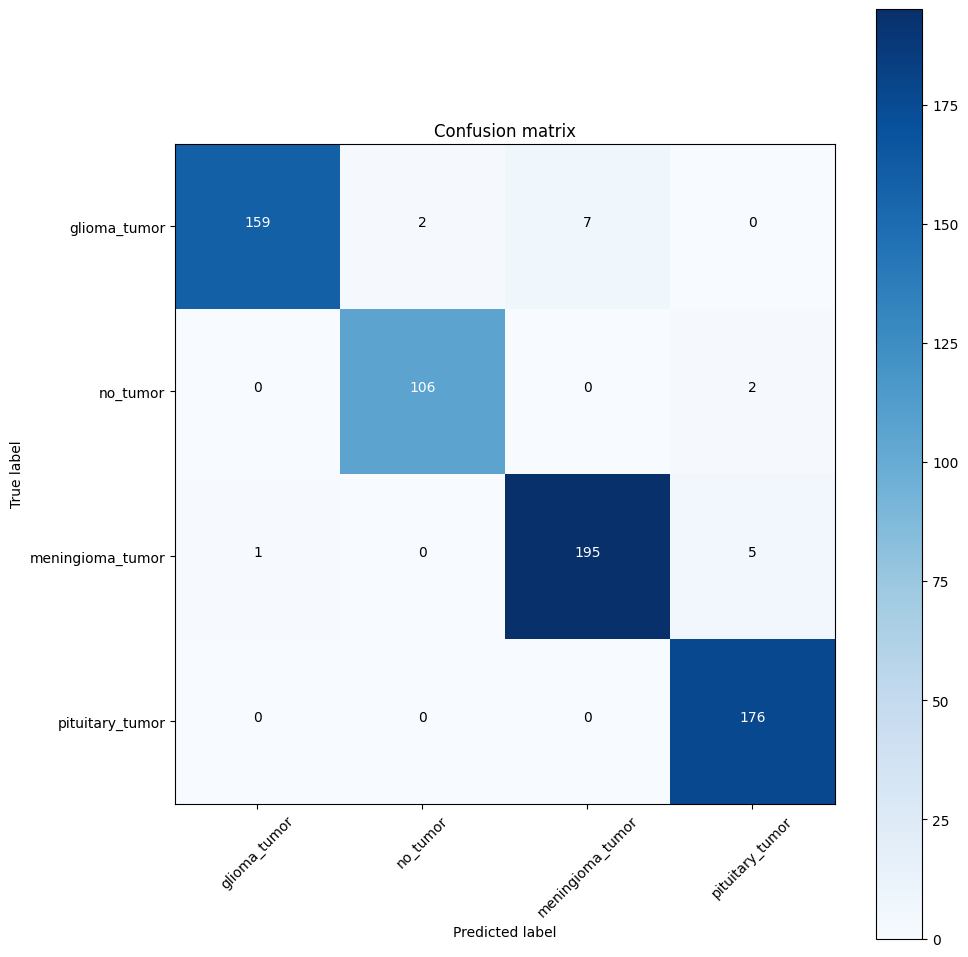

In [25]:
plot_confusion_matrix(cm,labels)


# Checking Model

In [26]:
def names(number):
    if number==0:
        return 'Its a Giloma Tumor'
    elif number==1:
        return ' Its not a Tumor'
    elif number==3:
        return ' Its a Pituitary  tumor'
    if number==2 :
        return ' Its a Meningioma tumor'
 

2026-02-17 10:21:48.480110: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-17 10:21:48.615637: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-17 10:21:49.324763: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-17 10:21:49.460832: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-17 10:21:50.183047: E external/local_xla/xla/stream_

75.62254% Confidence This Is  Its a Meningioma tumor


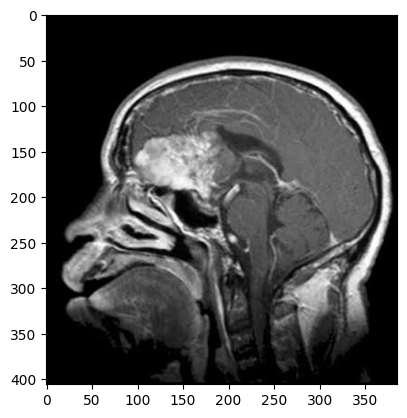

In [27]:
from matplotlib.pyplot import imshow
img = Image.open(r"/kaggle/input/datasets/sartajbhuvaji/brain-tumor-classification-mri/Testing/glioma_tumor/image(10).jpg")
x = np.array(img.resize((224,224)))
x = x.reshape(1,224,224,3)
res = model.predict_on_batch(x)
classification = np.where(res == np.amax(res))[1][0]
imshow(img)
print(str(res[0][classification]*100) + '% Confidence This Is ' + names(classification))

99.99971% Confidence This Is  Its a Pituitary  tumor


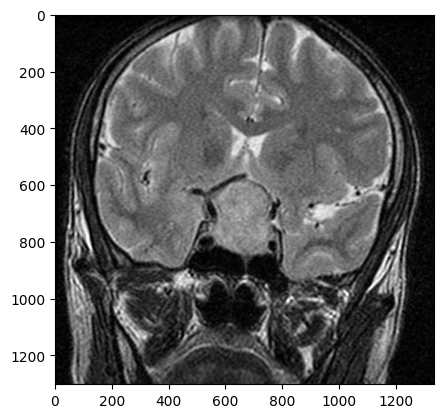

In [28]:
from matplotlib.pyplot import imshow
img = Image.open(r"/kaggle/input/datasets/sartajbhuvaji/brain-tumor-classification-mri/Testing/pituitary_tumor/image(44).jpg")
x = np.array(img.resize((224,224)))
x = x.reshape(1,224,224,3)
res = model.predict_on_batch(x)
classification = np.where(res == np.amax(res))[1][0]
imshow(img)
print(str(res[0][classification]*100) + '% Confidence This Is ' + names(classification))

99.922035% Confidence This Is  Its not a Tumor


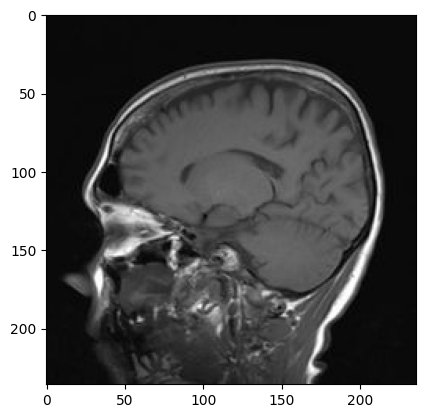

In [29]:
from matplotlib.pyplot import imshow
img = Image.open(r"/kaggle/input/datasets/sartajbhuvaji/brain-tumor-classification-mri/Testing/no_tumor/image(19).jpg")
x = np.array(img.resize((224,224)))
x = x.reshape(1,224,224,3)
res = model.predict_on_batch(x)
classification = np.where(res == np.amax(res))[1][0]
imshow(img)
print(str(res[0][classification]*100) + '% Confidence This Is ' + names(classification))

In [30]:
import pickle
with open('brain_tumor_model.pkl', 'wb') as f:
    pickle.dump(model, f)
print("Done!")

Done!


In [31]:
import tensorflow as tf
print(tf.__version__)
import keras
print(keras.__version__)

2.19.0
3.10.0


In [32]:
# After training, save as .keras (NOT pickle)
model.save("brain_tumor_model.keras")